# COMMEMI 2D-4 Inversion Demo

使用 `MT2DTrueModels.create_commemi_2d4` 生成标准模型并执行 2D MT 反演。

In [1]:
import os
import sys
import torch
import numpy as np

current_path = os.path.abspath("")
root_path = os.path.abspath(os.path.join(current_path, "..", ".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

from src.mt2d_inv import MT2DInverterWeightedCost, MT2DTrueModels

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")

Running on cuda


In [2]:
# 1) Build COMMEMI 2D-1 true model
yn, zn, nza, sig_true = MT2DTrueModels.create_commemi_2d4(
    nza=10,
    device=device,
    
)

# 2) Survey setup
freqs = torch.logspace(0.5, -6, 30, device=device)
stations = torch.linspace(-15000.0, 15000.0, 31, device=device)

print(f"Grid (nz, ny): {(len(zn)-1, len(yn)-1)}")
print(f"Stations: {len(stations)}, Freqs: {len(freqs)}")

Grid (nz, ny): (40, 40)
Stations: 31, Freqs: 30


✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.1, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.1, scale=0.9, reach=None
Generating 2D MT synthetic data...
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ 2D data error propagation completed
Computing data weights (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ MSE data weights normalized (mean): scale=5.843573e+01
✓ Synthetic data generated
  -> Impedance noise level: 1.0% (gaussian)
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


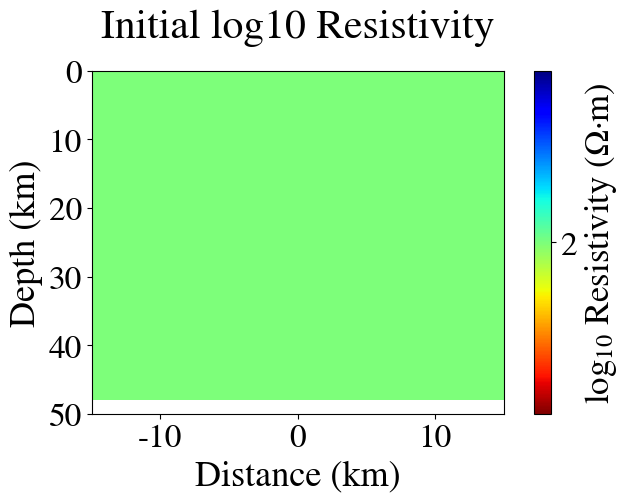

In [3]:
# 3) Inverter + synthetic data
inv = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    te_weight=1.0,
    tm_weight=5.0,
    data_loss_scale=10000,
    ot_options={"blur": 0.1}
)
inv.set_forward_operator()
inv.sig_true = sig_true
inv.create_synthetic_data(noise_level=0.01, noise_type="gaussian")
inv.initialize_model(initial_sigma=0.01)
inv.plot_initial_model(clip_to_stations=True, ylim=[50, 0],synthetic_figwidth_scale=2.0)

In [4]:
# 4) Run inversion
final_sigma = inv.run_inversion(
    n_epochs=200,
    mode="3dot",
    progress_interval=20,
    current_lambda=1.0,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.5,
    enable_blur_anneal=True,
    profile_timing = True
)
print("Inversion done")
print(final_sigma.min().item(), final_sigma.max().item())

✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
  [Timing ms] forward=618 | data_term=125 (17.2%) | backward=597 (82.3%) | data_prep=4 | data_term+backward+prep=725ms (100.0% of main) | probe_d=693 probe_m=1 step=65 reg=0
Epoch 1/200 [   0.5%]
  Elapsed: 0:00:03 | Remaining: ~0:07:01 | ETA: 10:45:51
  Epoch time: 2.12s | Avg: 2.12s
  Total: 1.7612e+03 | Data(3dot): 1.7612e+03
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 63.235 | Rough: 0.00e+00 | Lam: 1.0000000
  GradNorms: |g_d|=nan | |λ·g_m|=nan
  [Timing ms] forward=635 | data_term=116 (15.4%) | backward=632 (83.8%) | data_prep=6 | data_term+backward+prep=754ms (100.0% of main) | probe_d=625 probe_m=1 step=4 reg=1
Epoch 21/200 [  10.5%]
  Elapsed: 0:00:47 | Remaining: ~0:06:35 | ETA: 10:46:09
  Epoch time: 2.60s | Avg: 2.21s
  Total: 6.3760e+02 | Data(3dot): 6.2666e+02
  Misfit(RMS χ²): 44.957 | Rough: 1.09e+01 | Lam: 1.0000000
  GradNorms: |g_d|=1.797e+00 | |λ·g_m|=1.246e-01
  [Timing ms] forward=

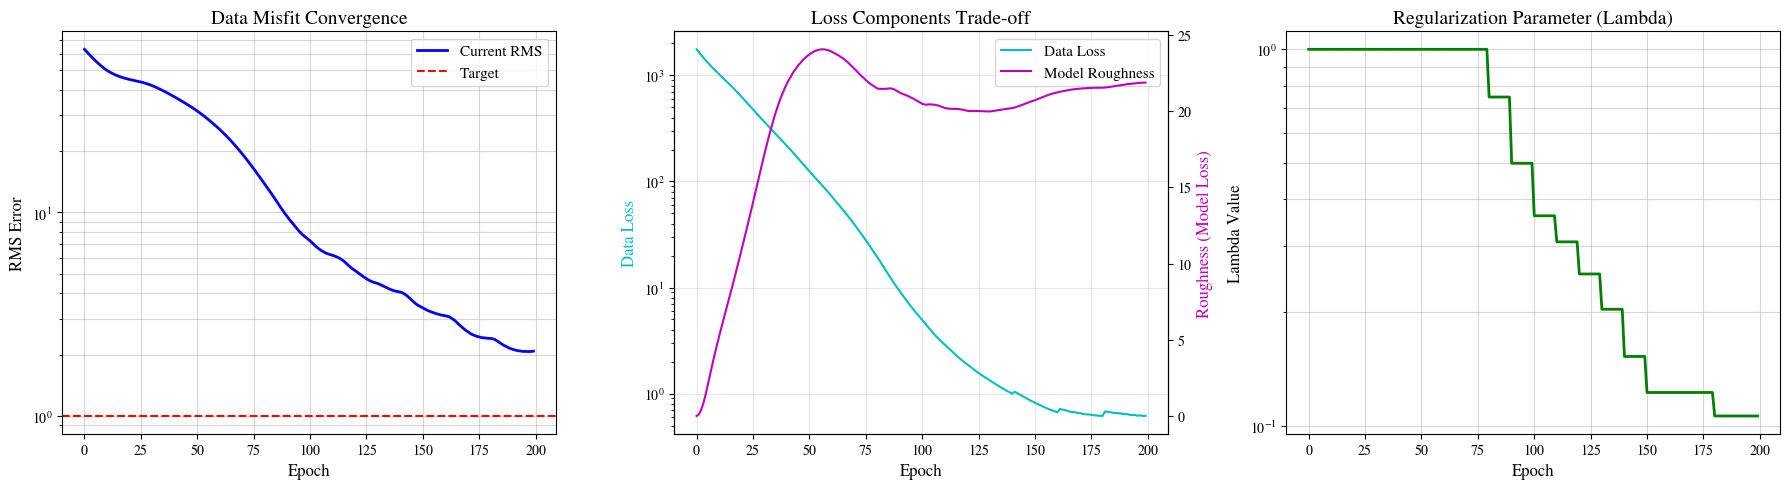

Model structural similarity (SSIM): 0.8506


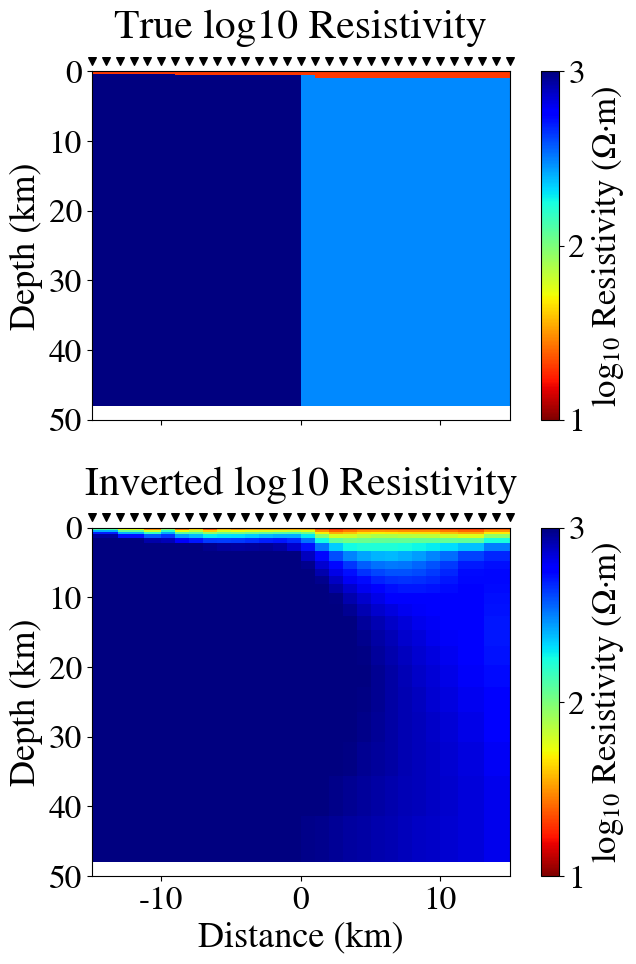

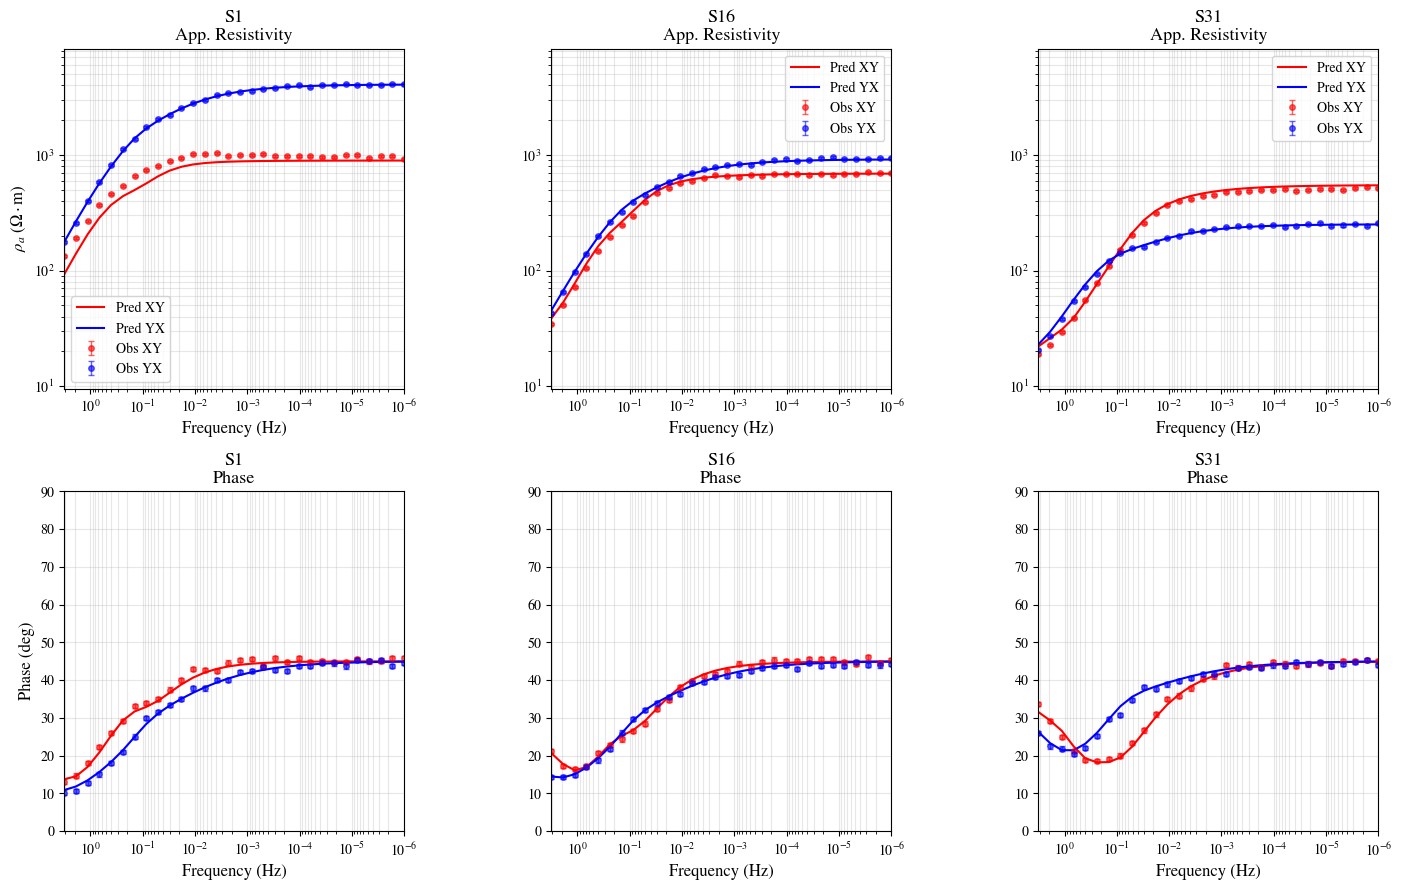

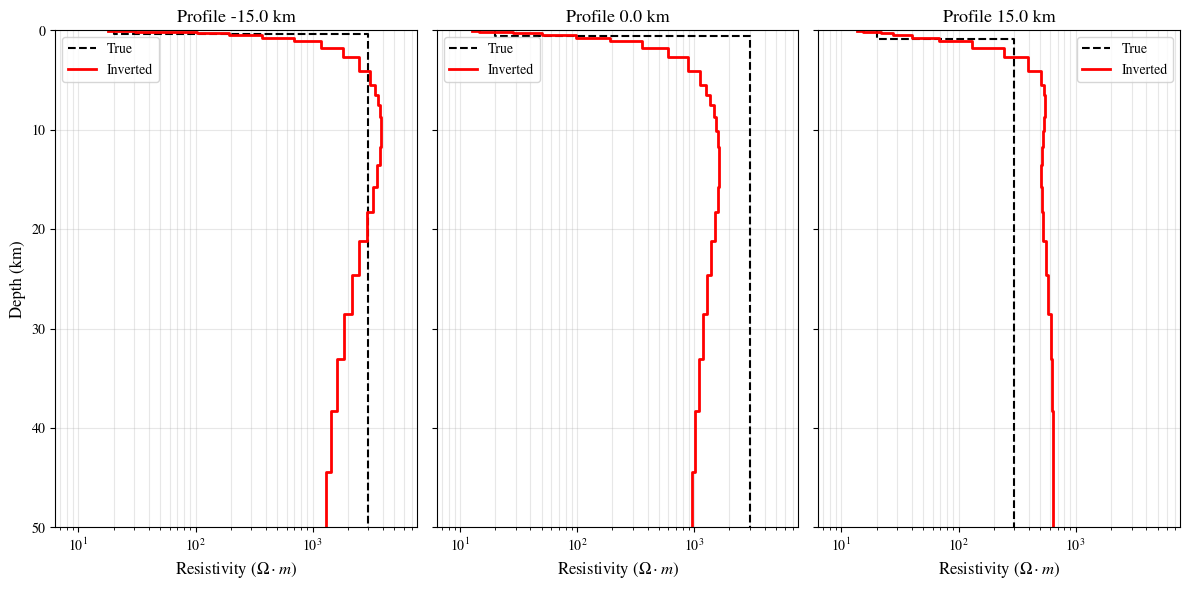

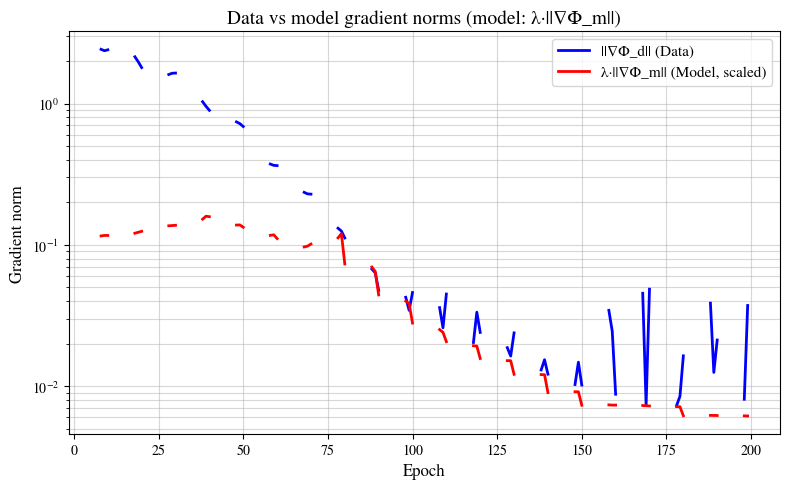

In [5]:
# 5) Plot results
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0
)
inv.plot_data_fitting()
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [6]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch

def misfit_rel_drop_stats(h: pd.DataFrame, block: int = 100, col: str = "misfit"):
    """按 epoch 排序后，每 block 个 epoch 为一段：段首→段末的相对下降率。"""
    h = h.sort_values("epoch").reset_index(drop=True)
    s = h[col].to_numpy(dtype=float)
    n = len(s)
    drops = []
    for b in range(0, n // block):
        i0 = b * block
        i1 = i0 + block - 1
        if i1 >= n:
            break
        a, z = s[i0], s[i1]
        if np.isfinite(a) and abs(a) > 1e-15 and np.isfinite(z):
            drops.append((a - z) / abs(a))
    if not drops:
        return {
            "rms_rel_drop_mean_100ep": np.nan,
            "rms_rel_drop_last_100ep": np.nan,
            "rms_rel_drop_std_100ep": np.nan,
            "n_100ep_blocks": 0,
        }
    arr = np.array(drops, dtype=float)
    return {
        "rms_rel_drop_mean_100ep": float(np.mean(arr)),
        "rms_rel_drop_last_100ep": float(arr[-1]),
        "rms_rel_drop_std_100ep": float(np.std(arr)),
        "n_100ep_blocks": len(arr),
    }

# =====================================================================
# 直接从已完成的 inv 对象提取数据
# =====================================================================
h = pd.DataFrame(inv.loss_history)
p = inv.time_stats.get("profile", {})

# 构造当前反演的性能记录字典
row = {
    "epochs_done": len(h),
    "total_inversion_time_s": float(inv.time_stats.get("total_inversion_time", np.nan)),
    "avg_epoch_time_s": float(inv.time_stats.get("avg_epoch_time", np.nan)),
    "final_misfit": float(h["misfit"].iloc[-1]) if len(h) else np.nan,
    "best_misfit": float(h["misfit"].min()) if len(h) else np.nan,
    
    # 提取微观探针耗时
    "forward_ms": float(p.get("forward_ms", np.nan)),
    "data_prep_ms": float(p.get("data_prep_ms", np.nan)),
    "data_term_ms": float(p.get("data_term_ms", np.nan)),
    "backward_ms": float(p.get("backward_ms", np.nan)),
    "step_ms": float(p.get("step_ms", np.nan)),
    "regularization_ms": float(p.get("regularization_ms", np.nan)),
}

# 补充收敛下降率统计
row.update(misfit_rel_drop_stats(h, block=100))

# 补充显存峰值（如果在 CUDA 上）
if str(inv.device).startswith("cuda"):
    row["peak_gpu_mem_GB"] = float(torch.cuda.max_memory_allocated(inv.device) / 1024**3)

# 转换为单行 DataFrame
summary = pd.DataFrame([row])

# =====================================================================
# 保存文件
# =====================================================================
# 保存文件 (按模型建文件夹，按模式命名文件)
# =====================================================================
PERF_ROOT = Path.cwd() / "性能参数"

def infer_mode_tag(inv_obj):
    m = getattr(inv_obj, "_last_inversion_mode", None)
    if m is None and hasattr(inv_obj, "loss_history") and len(inv_obj.loss_history) > 0:
        m = "unknown_mode"
    return str(m or "unknown_mode")
    
MODEL_TAG = "commemi_2d4"

def infer_model_tag(inv_obj):
    # 优先使用显式标签
    if "MODEL_TAG" in globals() and globals()["MODEL_TAG"]:
        return str(globals()["MODEL_TAG"])
    mt = getattr(inv_obj, "model_tag", None)
    if mt:
        return str(mt)

    # 自动回退
    sig_true = getattr(inv_obj, "sig_true", None)
    if isinstance(sig_true, torch.Tensor):
        if len(inv_obj.stations) == 31 and len(inv_obj.freqs) == 30:
            return model_name
        return "synthetic"
    return "realdata"

# 获取动态标签
mode_tag = infer_mode_tag(inv)
model_tag = infer_model_tag(inv)

# 1. 建立以模型命名的主文件夹 (例如: 性能参数/commemi_2d4)
out_dir = PERF_ROOT / model_tag
out_dir.mkdir(parents=True, exist_ok=True)

# 异常时间排查提示
if not p:
    print("[提示] time_stats['profile'] 为空：通常是 run_inversion 未设置 profile_timing=True，或当前 inv 不是本次反演对象。")
else:
    timing_keys = ["forward_ms", "data_prep_ms", "data_term_ms", "backward_ms", "step_ms", "regularization_ms"]
    empty_keys = [k for k in timing_keys if not np.isfinite(float(row.get(k, np.nan)))]
    if empty_keys:
        print(f"[提示] 以下时间项为空: {empty_keys}。请确认 profile_timing=True，且该单元在反演结束后、同一内核内执行。")

# 2. 按照模式名称生成具体的文件名 (例如: summary_6dot.csv)
summary_file = out_dir / f"summary_{mode_tag}.csv"
history_file = out_dir / f"history_{mode_tag}.csv"

# 3. 保存 CSV 文件
summary.to_csv(summary_file, index=False, encoding="utf-8-sig")
h.to_csv(history_file, index=False, encoding="utf-8-sig")

print(f"数据已保存至: {out_dir.resolve()}")
display(summary)

数据已保存至: /home/liuxr/MTinv-OT/synthetic_tests/test_mt2d/性能参数/commemi_2d4


,epochs_done,total_inversion_time_s,avg_epoch_time_s,final_misfit,best_misfit,forward_ms,data_prep_ms,data_term_ms,backward_ms,step_ms,regularization_ms,rms_rel_drop_mean_100ep,rms_rel_drop_last_100ep,rms_rel_drop_std_100ep,n_100ep_blocks,peak_gpu_mem_GB
0,200,434.103269,2.165497,2.082026,2.072208,640.461515,4.342241,112.157015,602.137101,1.313154,0.77575,0.797842,0.712901,0.084941,2,0.292993
